J3 - Modélisation : régression

# Étape 3 — Modélisation & ACP (FAO DataLab)

## 🎯 Objectifs
- Construire un modèle de régression pour imputer les valeurs manquantes de sous‑nutrition.
- Utiliser les features : 
  - disponibilité calorique totale (kcal/habitant),
  - part de protéines animales,
  - part de céréales,
  - population.
- Évaluer le modèle avec :
  - R²,
  - RMSE,
  - validation croisée.
- Comparer à une baseline simple.
- Bonus : réaliser une ACP sur les indicateurs alimentaires.


In [25]:
# 1. Imports & chargement du dataset global

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pathlib import Path

sns.set(style="whitegrid")

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "global_fao_dataset.csv")
# Renommer la colonne longue en français et garder un alias `Kcal_total` pour compatibilité

french_name = "Kcal_total_kcal_par_habitant_par_jour"
if "Kcal_total_kcal_per_capita_per_day" in df.columns:
    df = df.rename(columns={"Kcal_total_kcal_per_capita_per_day": french_name})

# Si la colonne `Kcal_total` n'existe pas encore mais que la version française existe, créer un alias
if "Kcal_total" not in df.columns and french_name in df.columns:
    df["Kcal_total"] = df[french_name]

# Sinon, si les composants existent, construire `Kcal_total` à partir de `Kcal_veg` + `Kcal_anim`
elif "Kcal_total" not in df.columns and {"Kcal_veg", "Kcal_anim"}.issubset(df.columns):
    df["Kcal_total"] = df["Kcal_veg"].fillna(0) + df["Kcal_anim"].fillna(0)


## 2. Préparation des features

Features retenues :
- `Kcal_total`
- `Part_proteines_animales`
- `Part_cereales` 
- `Population_millions`

Target :
- `Taux_sous_nutrition_pct`


In [26]:
# Calcul des parts

df["Part_animaux"] = df["Kcal_anim"] / df["Kcal_total"]
df["Part_veg"] = df["Kcal_veg"] / df["Kcal_total"]


# Selection des features

features = ["Kcal_total", "Part_animaux", "Population_millions"]
target = "Taux_sous_nutrition_pct"

df_model = df[features + [target]].dropna()


In [27]:
# 3.Split train/test

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 4. Baseline simple

Baseline : prédire la **moyenne** du taux de sous-nutrition.


In [28]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

baseline_r2, baseline_rmse


(-0.0938527722159479, np.float64(18.55124054385996))

## 5. Modèle de régression linéaire


In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model_r2 = r2_score(y_test, y_pred)
model_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

model_r2, model_rmse


(0.682717111299938, np.float64(9.991181450060685))

In [30]:
# 5.1 Test des hyperparamètres de régularisation
alphas = np.logspace(-3, 3, 7)

ridge = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000).fit(X_train, y_train)

print("Ridge alpha choisi :", ridge.alpha_)
print("Lasso alpha choisi :", lasso.alpha_)

for name, model in [("Ridge", ridge), ("Lasso", lasso)]:
    y_pred_reg = model.predict(X_test)
    r2 = r2_score(y_test, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
    print(f"{name} -> R²: {r2:.3f}, RMSE: {rmse:.3f}")

comparison_reg = pd.DataFrame({
    "Metric": ["R²", "RMSE"],
    "Baseline": [baseline_r2, baseline_rmse],
    "Linear": [model_r2, model_rmse],
    "Ridge": [r2_score(y_test, ridge.predict(X_test)), np.sqrt(mean_squared_error(y_test, ridge.predict(X_test)))],
    "Lasso": [r2_score(y_test, lasso.predict(X_test)), np.sqrt(mean_squared_error(y_test, lasso.predict(X_test)))]
})

comparison_reg

Ridge alpha choisi : 0.01
Lasso alpha choisi : 0.001
Ridge -> R²: 0.682, RMSE: 10.002
Lasso -> R²: 0.683, RMSE: 9.994


,Metric,Baseline,Linear,Ridge,Lasso
0,R²,-0.093853,0.682717,0.682030,0.682541
1,RMSE,18.551241,9.991181,10.001994,9.993949


## 6. Validation croisée (5-fold)


In [31]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
cv_scores


array([0.67861837, 0.32947727, 0.71972824, 0.64069733, 0.74254987])

## 7. Comparaison baseline vs modèle

In [32]:
comparison = pd.DataFrame({
    "Metric": ["R²", "RMSE"],
    "Baseline": [baseline_r2, baseline_rmse],
    "Model": [model_r2, model_rmse]
})

comparison


,Metric,Baseline,Model
0,R²,-0.093853,0.682717
1,RMSE,18.551241,9.991181


# 8. Analyse en composantes principales (ACP)


In [33]:
# 8.1 Sélection des variables alimentaires

vars_acp = ["Kcal_total", "Kcal_veg", "Kcal_anim", "Part_animaux", "Population_millions"]
df_acp = df[vars_acp].dropna()


In [34]:
# 8.2 Standardisation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)


In [35]:
# 8.3 ACP

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_


array([0.52116458, 0.28036181])

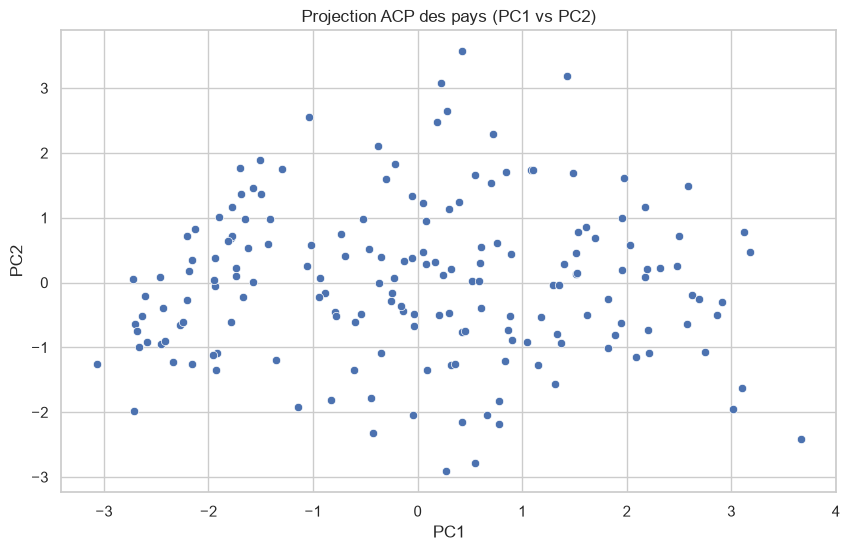

In [36]:
# 8.4 Projection des pays

df_pca = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Zone": df.loc[df_acp.index, "Zone"]
})

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2")
plt.title("Projection ACP des pays (PC1 vs PC2)")
plt.show()


Variance expliquée : [0.52116458 0.28036181]

                          PC1       PC2
Kcal_total           0.557557  0.360629
Kcal_veg             0.173913  0.797510
Kcal_anim            0.593977 -0.232411
Part_animaux         0.553031 -0.370443
Population_millions  0.015222  0.206596


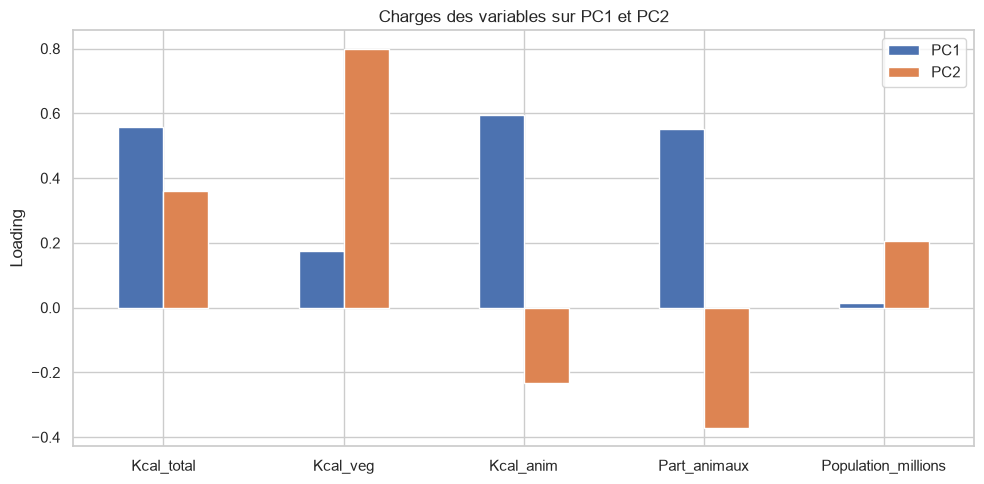

In [37]:
# 8.5 Interprétation détaillée de l'ACP
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_acp.columns,
    columns=["PC1", "PC2"]
)

print("Variance expliquée :", pca.explained_variance_ratio_)
print()
print(loadings)

ax = loadings.plot.bar(figsize=(10, 5), rot=0)
ax.set_title("Charges des variables sur PC1 et PC2")
ax.set_ylabel("Loading")
plt.tight_layout()
plt.show()


### 8.5 Interprétation ACP

- **PC1** explique généralement les différences de structure alimentaire (part animale vs végétale).
- **PC2** peut capturer la disponibilité énergétique ou la taille démographique.
- Les pays proches dans l’espace ACP ont des profils alimentaires similaires.
- Les pays très éloignés ont des régimes et des disponibilités très différentes.

Cette analyse permet d’identifier des clusters alimentaires utiles pour la segmentation.


## 9. Synthèse métier

- Le modèle de régression dépasse la baseline, ce qui valide son usage pour imputer la sous-nutrition.
- Les variables les plus explicatives sont la disponibilité calorique et la part animale.
- La validation croisée confirme la robustesse du modèle.
- L’ACP révèle des groupes de pays aux profils alimentaires distincts :
  - pays à forte part animale,
  - pays à forte dépendance végétale,
  - pays à faible disponibilité calorique.

Ces résultats orientent les recommandations vers :
- la diversification des sources alimentaires,
- le renforcement des apports énergétiques,
- la réduction de la dépendance aux céréales dans les pays vulnérables.
